In [1]:
%load_ext autoreload
%autoreload 3

In [2]:
import numpy as np
from collections import Counter
import math
import pandas as pd
import matplotlib.pyplot as plt
from methods import (CriterionNode, HierarchicalElectreTriB, set_equal_weights_topdown, class_acceptability_smaa, 
                     plot_country_pies_smaa, plot_acceptability_smaa, params_to_df, country_hierarchy, compute_lambdas)

In [3]:
raw = pd.read_csv("Freedom_and_Prosperity.csv", decimal=",")
print(f"Raw data: {raw.shape[0]} rows x {raw.shape[1]} columns")

# criteria
leaf_cols = [
    # Economic subindex
    "Proper_Rights", "Trade_Freedom", "Investm_Freedom", "Womens_Economic_Freedom",
    # Political subindex
    "PF_Elections", "Civil_Liberties", "Political_Rights", "Legislative_Constraints_on_the_Executive",
    # Legal subindex
    "Clarity_of_the_Law", "Judicial_Independence_and_Effectiveness", "Bureaucracy_and_Corruption",
    "Security", "Informality",
    # Prosperity
    "Income", "Environment", "Minorities", "Health", "Education", "Inequality",
]

# Keep only countries and only the year 2024
df = raw[(raw["Index_Year"] == 2024) & (raw["ISO3"].notna())].copy()
print(f"Countries in 2024: {df.shape[0]}")

# Drop countries with missing values in the elementary criteria
df = df.dropna(subset=leaf_cols)
print(f"Complete countries (no missing values): {df.shape[0]}")

# Keep only the criteria columns, indexed by country name
df = df.set_index("Name")[leaf_cols]
print(f"\n{df.shape[0]} countries x {df.shape[1]} criteria")

df.head()

Raw data: 5610 rows x 57 columns
Countries in 2024: 164
Complete countries (no missing values): 151

151 countries x 19 criteria


,Proper_Rights,Trade_Freedom,Investm_Freedom,Womens_Economic_Freedom,PF_Elections,Civil_Liberties,Political_Rights,Legislative_Constraints_on_the_Executive,Clarity_of_the_Law,Judicial_Independence_and_Effectiveness,Bureaucracy_and_Corruption,Security,Informality,Income,Environment,Minorities,Health,Education,Inequality
Name,,,,,,,,,,,,,,,,,,,
Angola,33.909381,33.410951,30.0,79.375,76.466667,64.30,55.35,17.2,45.983607,44.040167,29.926194,57.477784,56.946183,50.147485,60.720898,41.396151,63.271312,50.720767,36.342593
Albania,44.205751,93.027856,60.0,91.250,82.900000,93.25,75.90,68.2,57.076503,70.222170,45.890337,68.104440,73.091364,65.245762,70.600380,59.442325,90.660184,73.716172,63.657407
United Arab Emirates,76.338100,88.628857,50.0,82.500,29.866667,46.30,5.25,13.8,66.543716,39.614388,75.545517,78.110082,79.224030,87.491842,76.744827,51.453732,96.704562,87.557582,80.324074
Argentina,47.924284,43.020571,65.0,79.375,95.733333,87.60,81.15,81.6,53.524590,69.624609,39.167640,61.810356,71.214018,72.069277,74.537699,74.048145,86.626334,88.536107,63.657407
Armenia,54.473859,85.140215,70.0,90.625,89.233333,82.20,80.95,61.0,59.986339,48.077975,45.870747,47.601900,56.445557,66.366509,69.386882,62.291859,83.497222,77.623469,72.222222


In [4]:
df.to_csv("dataframe_clean.csv")

In [5]:
Economic = CriterionNode("Economic_Subindex",
                         children=[
                             CriterionNode("Proper_Rights", leaf_id="Proper_Rights"),
                             CriterionNode("Trade_Freedom", leaf_id="Trade_Freedom"),
                             CriterionNode("Investm_Freedom", leaf_id="Investm_Freedom"),
                             CriterionNode("Womens_Economic_Freedom", leaf_id="Womens_Economic_Freedom"),
                         ])

Political = CriterionNode("Political_Subindex",
                          children=[
                              CriterionNode("PF_Elections", leaf_id="PF_Elections"),
                              CriterionNode("Civil_Liberties", leaf_id="Civil_Liberties"),
                              CriterionNode("Political_Rights", leaf_id="Political_Rights"),
                              CriterionNode("Legislative_Constraints_on_the_Executive",
                                            leaf_id="Legislative_Constraints_on_the_Executive"),
                          ])

Legal = CriterionNode("Legal_Subindex",
                      children=[
                          CriterionNode("Clarity_of_the_Law", leaf_id="Clarity_of_the_Law"),
                          CriterionNode("Judicial_Independence_and_Effectiveness",
                                        leaf_id="Judicial_Independence_and_Effectiveness"),
                          CriterionNode("Bureaucracy_and_Corruption", leaf_id="Bureaucracy_and_Corruption"),
                          CriterionNode("Security", leaf_id="Security"),
                          CriterionNode("Informality", leaf_id="Informality"),
                      ])

Freedom = CriterionNode("Freedom",
                        children=[Economic, Political, Legal])

Prosperity = CriterionNode("Prosperity",
                           children=[
                               CriterionNode("Income", leaf_id="Income"),
                               CriterionNode("Environment", leaf_id="Environment"),
                               CriterionNode("Minorities", leaf_id="Minorities"),
                               CriterionNode("Health", leaf_id="Health"),
                               CriterionNode("Education", leaf_id="Education"),
                               CriterionNode("Inequality", leaf_id="Inequality"),
                           ])

Root = CriterionNode("Freedom_and_Prosperity",
                     children=[Freedom, Prosperity])

In [6]:
leaves = Root.leaves()
print(f"{len(leaves)} elementary criteria (leaves):")
print(leaves)

19 elementary criteria (leaves):
['Proper_Rights', 'Trade_Freedom', 'Investm_Freedom', 'Womens_Economic_Freedom', 'PF_Elections', 'Civil_Liberties', 'Political_Rights', 'Legislative_Constraints_on_the_Executive', 'Clarity_of_the_Law', 'Judicial_Independence_and_Effectiveness', 'Bureaucracy_and_Corruption', 'Security', 'Informality', 'Income', 'Environment', 'Minorities', 'Health', 'Education', 'Inequality']


In [7]:
weights = set_equal_weights_topdown(Root, 1.0)

print("weights per leaf:")
for lf in leaves:
    print(f"  {lf:42s} w = {weights[lf]:.4f}")
print(f"\nsum Freedom    = {sum(weights[lf] for lf in Freedom.leaves()):.4f}")
print(f"sum Prosperity = {sum(weights[lf] for lf in Prosperity.leaves()):.4f}")
for sub in (Economic, Political, Legal):
    print(f"sum {sub.name:18s} = {sum(weights[lf] for lf in sub.leaves()):.4f}")

weights per leaf:
  Proper_Rights                              w = 0.0417
  Trade_Freedom                              w = 0.0417
  Investm_Freedom                            w = 0.0417
  Womens_Economic_Freedom                    w = 0.0417
  PF_Elections                               w = 0.0417
  Civil_Liberties                            w = 0.0417
  Political_Rights                           w = 0.0417
  Legislative_Constraints_on_the_Executive   w = 0.0417
  Clarity_of_the_Law                         w = 0.0333
  Judicial_Independence_and_Effectiveness    w = 0.0333
  Bureaucracy_and_Corruption                 w = 0.0333
  Security                                   w = 0.0333
  Informality                                w = 0.0333
  Income                                     w = 0.0833
  Environment                                w = 0.0833
  Minorities                                 w = 0.0833
  Health                                     w = 0.0833
  Education                   

In [8]:
q = {lf: 4.0 for lf in leaves}
p = {lf: 6.0 for lf in leaves}
v = {lf: 40.0 for lf in leaves}

lambda_frac = 0.75
lambdas = compute_lambdas(Root, weights, lambda_frac)

print("lambdas per node:")
for name, lam in lambdas.items():
    print(f"  {name:42s} lambda = {lam:.4f}")

categories = ["Class_1", "Class_2", "Class_3", "Class_4"]  # Class_4 is the best
b1 = {lf: 40.0 for lf in leaves}  # boundary profile between Class_1 and Class_2
b2 = {lf: 60.0 for lf in leaves}  # boundary profile between Class_2 and Class_3
b3 = {lf: 80.0 for lf in leaves}  # boundary profile between Class_3 and Class_4
profiles = {"b1": b1, "b2": b2, "b3":b3}

lambdas per node:
  Freedom_and_Prosperity                     lambda = 0.7500
  Freedom                                    lambda = 0.3750
  Economic_Subindex                          lambda = 0.1250
  Political_Subindex                         lambda = 0.1250
  Legal_Subindex                             lambda = 0.1250
  Prosperity                                 lambda = 0.3750


In [9]:
model = HierarchicalElectreTriB(
    root=Root,
    weights=weights,
    q=q,
    p=p,
    v=v,
    lambdas=lambdas,
    profiles=profiles,
    categories=categories,
    relation="O3")

In [10]:
def classify(procedure):
    alternatives_dict = {}
    for alternative_name in df.index:
        alt = df.loc[alternative_name].to_dict()
        alternatives_dict[alternative_name] = model.assign_all_nodes(alt, procedure=procedure)
    return pd.DataFrame(alternatives_dict).T


res_pess = classify("pessimistic")

# order the columns
node_order = list(lambdas.keys())
res_pess = res_pess[node_order]
res_pess

,Freedom_and_Prosperity,Freedom,Economic_Subindex,Political_Subindex,Legal_Subindex,Prosperity
Angola,Class_2,Class_1,Class_1,Class_1,Class_2,Class_2
Albania,Class_3,Class_3,Class_2,Class_3,Class_2,Class_3
United Arab Emirates,Class_2,Class_1,Class_3,Class_1,Class_2,Class_3
Argentina,Class_3,Class_2,Class_2,Class_4,Class_2,Class_3
Armenia,Class_3,Class_2,Class_3,Class_3,Class_2,Class_3
...,...,...,...,...,...,...
Vietnam,Class_2,Class_1,Class_3,Class_1,Class_2,Class_3
Yemen,Class_1,Class_1,Class_1,Class_1,Class_1,Class_1
South Africa,Class_2,Class_2,Class_2,Class_4,Class_2,Class_1
Zambia,Class_2,Class_2,Class_2,Class_4,Class_2,Class_2


Distribution in the global class (Freedom_and_Prosperity):
Freedom_and_Prosperity
Class_1    30
Class_2    59
Class_3    33
Class_4    29
Name: count, dtype: int64


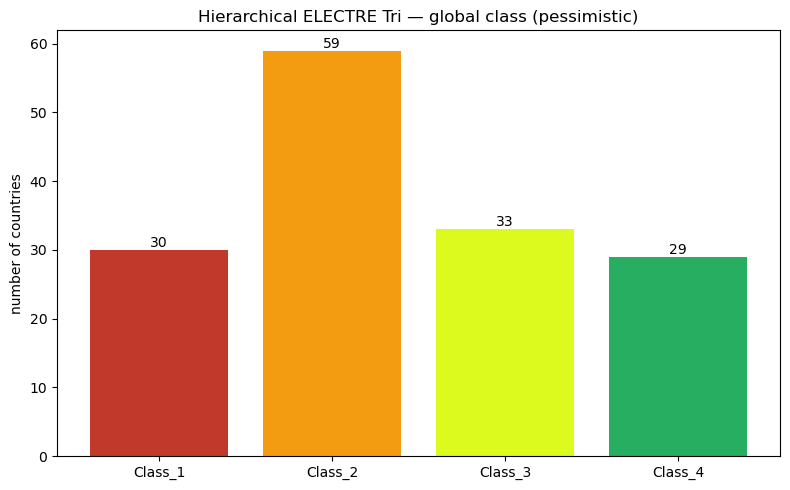

In [11]:
class_counts = res_pess["Freedom_and_Prosperity"].value_counts().reindex(categories, fill_value=0)
print("Distribution in the global class (Freedom_and_Prosperity):")
print(class_counts)

fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(class_counts.index, class_counts.values, color=["#c0392b", "#f39c12", "#ddfa1f", "#27ae60"])
ax.set_ylabel("number of countries")
ax.set_title("Hierarchical ELECTRE Tri — global class (pessimistic)")
for x, y in zip(class_counts.index, class_counts.values):
    ax.text(x, y, str(y), ha="center", va="bottom")
plt.tight_layout()
plt.show()


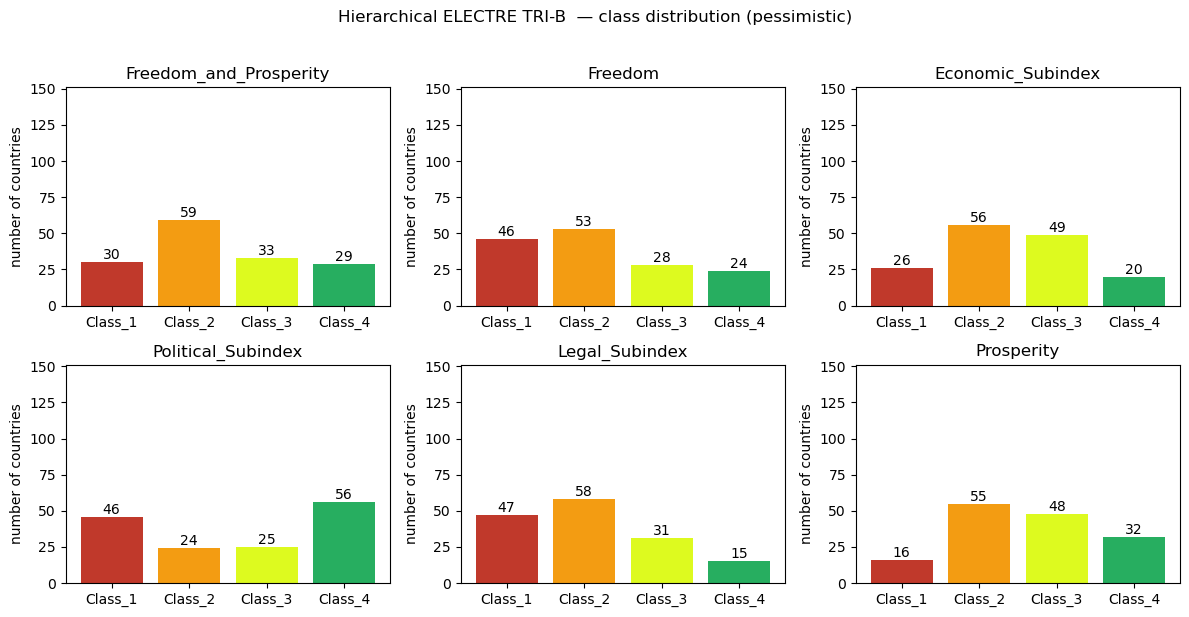

In [12]:
nodes = list(lambdas.keys())  # root + dimensions + subdimensions
colors = {"Class_1": "#c0392b", "Class_2": "#f39c12", "Class_3": "#ddfa1f", "Class_4": "#27ae60"}

ncols = 3
nrows = math.ceil(len(nodes) / ncols)
fig, axes = plt.subplots(nrows, ncols, figsize=(4 * ncols, 3 * nrows))
axes = axes.flatten()

for ax, node in zip(axes, nodes):
    class_counts = res_pess[node].value_counts().reindex(categories, fill_value=0)
    ax.bar(class_counts.index, class_counts.values, color=[colors[c] for c in class_counts.index])
    ax.set_title(node)
    ax.set_ylabel("number of countries")
    ax.set_ylim(0, len(df))
    for x, y in zip(class_counts.index, class_counts.values):
        ax.text(x, y, str(y), ha="center", va="bottom")

# turn off the leftover subplots
for ax in axes[len(nodes):]:
    ax.axis("off")

fig.suptitle("Hierarchical ELECTRE TRI-B  — class distribution (pessimistic)",
             y=1.02)
plt.tight_layout()
plt.show()

In [13]:
_ = country_hierarchy("Brazil", Root, df, res_pess)

Country: Brazil
Freedom_and_Prosperity                                  -> Class_3
  Freedom                                               -> Class_2
    Economic_Subindex                                   -> Class_2
      Proper_Rights                                        (value = 61.94)
      Trade_Freedom                                        (value = 79.28)
      Investm_Freedom                                      (value = 40.00)
      Womens_Economic_Freedom                              (value = 85.00)
    Political_Subindex                                  -> Class_4
      PF_Elections                                         (value = 94.83)
      Civil_Liberties                                      (value = 80.95)
      Political_Rights                                     (value = 91.00)
      Legislative_Constraints_on_the_Executive             (value = 93.60)
    Legal_Subindex                                      -> Class_2
      Clarity_of_the_Law                         

# SMAA-TRI

## Fixed weights

In [14]:
N_SIM = 10000        
SEED = 42            

categories = ["Class_1", "Class_2", "Class_3", "Class_4"]  # Class_4 is the best

rng = np.random.default_rng(SEED)
nodes = list(lambdas.keys())
alt_dicts = {name: df.loc[name].to_dict() for name in df.index}

counts = {c: {n: Counter() for n in nodes} for c in df.index}
params_fixed_w = []

for _ in range(N_SIM):
    q_s  = {lf: rng.uniform(3, 5)  for lf in leaves}
    p_s  = {lf: rng.uniform(5, 7)  for lf in leaves}
    v_s  = {lf: rng.uniform(30, 50) for lf in leaves}
    b1_s = {lf: rng.uniform(35, 45) for lf in leaves}
    b2_s = {lf: rng.uniform(55, 65) for lf in leaves}
    b3_s = {lf: rng.uniform(75, 85) for lf in leaves}
    model.q, model.p, model.v = q_s, p_s, v_s
    model.profiles = {"b1": b1_s, "b2": b2_s, "b3": b3_s}
    params_fixed_w.append({"q": q_s, "p": p_s, "v": v_s, "b1": b1_s, "b2": b2_s, "b3": b3_s})

    for name, alt in alt_dicts.items():
        assigned = model.assign_all_nodes(alt, procedure="pessimistic")
        for n in nodes:
            counts[name][n][assigned[n]] += 1

params_fixed_w_df = params_to_df(params_fixed_w)
print(f"Simulation finished: {N_SIM} iterations.")
print(f"Parameters stored in 'params_fixed_w' (list of dicts) and "
      f"'params_fixed_w_df' {params_fixed_w_df.shape}.")

params_fixed_w_df

Simulation finished: 10000 iterations.
Parameters stored in 'params_fixed_w' (list of dicts) and 'params_fixed_w_df' (10000, 114).


param                 q                                                        \
id        Proper_Rights Trade_Freedom Investm_Freedom Womens_Economic_Freedom   
iteration                                                                       
0              4.547912      3.877757        4.717196                4.394736   
1              3.353546      4.713229        4.517039                4.438926   
2              4.267950      3.211795        3.280679                3.838229   
3              4.601768      4.187364        4.565248                4.590230   
4              4.960054      3.917121        4.568162                4.272817   
...                 ...           ...             ...                     ...   
9995           4.312794      4.801489        3.601573                4.297673   
9996           3.644762      3.028417        3.154162                4.075380   
9997           4.437972      4.499929        4.208617                4.227554   
9998           4.017967      4.560075        3.042194                4.519499   
9999           3.830390      3.337811        4.814988                3.524143   

param                                                    \
id        PF_Elections Civil_Liberties Political_Rights   
iteration                                                 
0             3.188355        4.951245         4.522279   
1             3.864186        4.254618         4.168196   
2             4.932464        4.192085         4.866046   
3             4.892054        3.506767         4.180152   
4             4.144826        3.290261         4.892049   
...                ...             ...              ...   
9995          3.718654        3.143052         3.609432   
9996          4.020170        4.067913         4.083134   
9997          4.068745        3.801431         4.775040   
9998          3.211137        4.286499         4.200479   
9999          3.574195        4.003742         3.498541   

param                                                                  \
id        Legislative_Constraints_on_the_Executive Clarity_of_the_Law   
iteration                                                               
0                                         4.572129           3.256227   
1                                         4.299693           3.168889   
2                                         4.608722           3.934763   
3                                         3.190098           4.232331   
4                                         3.602685           4.156034   
...                                            ...                ...   
9995                                      3.924120           3.233445   
9996                                      3.364774           4.772518   
9997                                      3.279267           3.155937   
9998                                      4.327158           3.330052   
9999                                      4.405726           4.715272   

param                                              ...  \
id        Judicial_Independence_and_Effectiveness  ...   
iteration                                          ...   
0                                        3.900772  ...   
1                                        3.831615  ...   
2                                        4.569527  ...   
3                                        3.342583  ...   
4                                        4.399552  ...   
...                                           ...  ...   
9995                                     3.235124  ...   
9996                                     4.950569  ...   
9997                                     4.550990  ...   
9998                                     4.664313  ...   
9999                                     3.223952  ...   

param                                          b3                             \
id        Judicial_Independence_and_Effectiveness Bureaucracy_and_Corruption   
iteration                                 

In [15]:
accept = {}
for name in df.index:
    row = {}
    for n in nodes:
        total = sum(counts[name][n].values())  
        for c in categories:
            row[(n, c)] = counts[name][n][c] / total
    accept[name] = row

acceptability = pd.DataFrame(accept).T
acceptability.columns = pd.MultiIndex.from_tuples(acceptability.columns, names=["node", "class"])
acceptability = acceptability[[(n, c) for n in nodes for c in categories]]

acceptability

node                 Freedom_and_Prosperity                         Freedom  \
class                               Class_1 Class_2 Class_3 Class_4 Class_1   
Angola                               0.1576  0.8424     0.0     0.0  0.9777   
Albania                              0.0000  0.0000     1.0     0.0  0.0000   
United Arab Emirates                 0.4336  0.5664     0.0     0.0  1.0000   
Argentina                            0.0000  0.0000     1.0     0.0  0.0000   
Armenia                              0.0000  0.0000     1.0     0.0  0.0000   
...                                     ...     ...     ...     ...     ...   
Vietnam                              0.1990  0.8010     0.0     0.0  0.9905   
Yemen                                1.0000  0.0000     0.0     0.0  1.0000   
South Africa                         0.2734  0.7266     0.0     0.0  0.0000   
Zambia                               0.0000  1.0000     0.0     0.0  0.0000   
Zimbabwe                             0.5572  0.4428     0.0     0.0  1.0000   

node                                         Economic_Subindex          ...  \
class                Class_2 Class_3 Class_4           Class_1 Class_2  ...   
Angola                0.0223  0.0000     0.0             0.959  0.0410  ...   
Albania               0.1033  0.8967     0.0             0.000  0.9856  ...   
United Arab Emirates  0.0000  0.0000     0.0             0.000  0.4719  ...   
Argentina             0.9148  0.0852     0.0             0.000  1.0000  ...   
Armenia               0.7074  0.2926     0.0             0.000  0.0508  ...   
...                      ...     ...     ...               ...     ...  ...   
Vietnam               0.0095  0.0000     0.0             0.000  0.5367  ...   
Yemen                 0.0000  0.0000     0.0             1.000  0.0000  ...   
South Africa          0.9668  0.0332     0.0             0.000  1.0000  ...   
Zambia                0.9838  0.0162     0.0             0.000  0.9994  ...   
Zimbabwe              0.0000  0.0000     0.0             1.000  0.0000  ...   

node                 Political_Subindex         Legal_Subindex          \
class                           Class_3 Class_4        Class_1 Class_2   
Angola                           0.0000  0.0000         0.2804  0.7196   
Albania                          0.8309  0.1691         0.0000  0.7878   
United Arab Emirates             0.0000  0.0000         0.0000  1.0000   
Argentina                        0.0000  1.0000         0.0000  1.0000   
Armenia                          1.0000  0.0000         0.0000  1.0000   
...                                 ...     ...            ...     ...   
Vietnam                          0.0000  0.0000         0.3679  0.6321   
Yemen                            0.0000  0.0000         1.0000  0.0000   
South Africa                     0.0000  1.0000         0.0000  0.9997   
Zambia                           0.0922  0.9078         0.0053  0.9947   
Zimbabwe                         0.0000  0.0000         1.0000  0.0000   

node                                 Prosperity                          
class                Class_3 Class_4    Class_1 Class_2 Class_3 Class_4  
Angola                0.0000     0.0     0.0000  1.0000  0.0000  0.0000  
Albania               0.2122     0.0     0.0000  0.0000  1.0000  0.0000  
United Arab Emirates  0.0000     0.0     0.0000  0.0000  0.9673  0.0327  
Argentina             0.0000     0.0     0.0000  0.0000  0.9719  0.0281  
Armenia               0.0000     0.0     0.0000  0.0000  1.0000  0.0000  
...                      ...     ...        ...     ...     ...     ...  
Vietnam               0.0000     0.0     0.0000  0.0015  0.9985  0.0000  
Yemen                 0.0000     0.0     1.0000  0.0000  0.0000  0.0000  
South Africa          0.0003     0.0     1.0000  0.0000  0.0000  0.0000  
Zambia                0.0000     0.0     0.1625  0.8375  0.0000  0.0000  
Zimbabwe              0.0000     0.0     0.0096  0.9904  0.0000  0.0000  

[151 rows x 24 col

In [16]:
class_acceptability_smaa(acceptability, categories, "Freedom_and_Prosperity").round(3)

class,Class_1,Class_2,Class_3,Class_4
Australia,0.0,0.0,0.0,1.0
Belgium,0.0,0.0,0.0,1.0
Switzerland,0.0,0.0,0.0,1.0
Czech Republic,0.0,0.0,0.0,1.0
Germany,0.0,0.0,0.0,1.0
...,...,...,...,...
Syria,1.0,0.0,0.0,0.0
Chad,1.0,0.0,0.0,0.0
Tajikistan,1.0,0.0,0.0,0.0
Venezuela,1.0,0.0,0.0,0.0


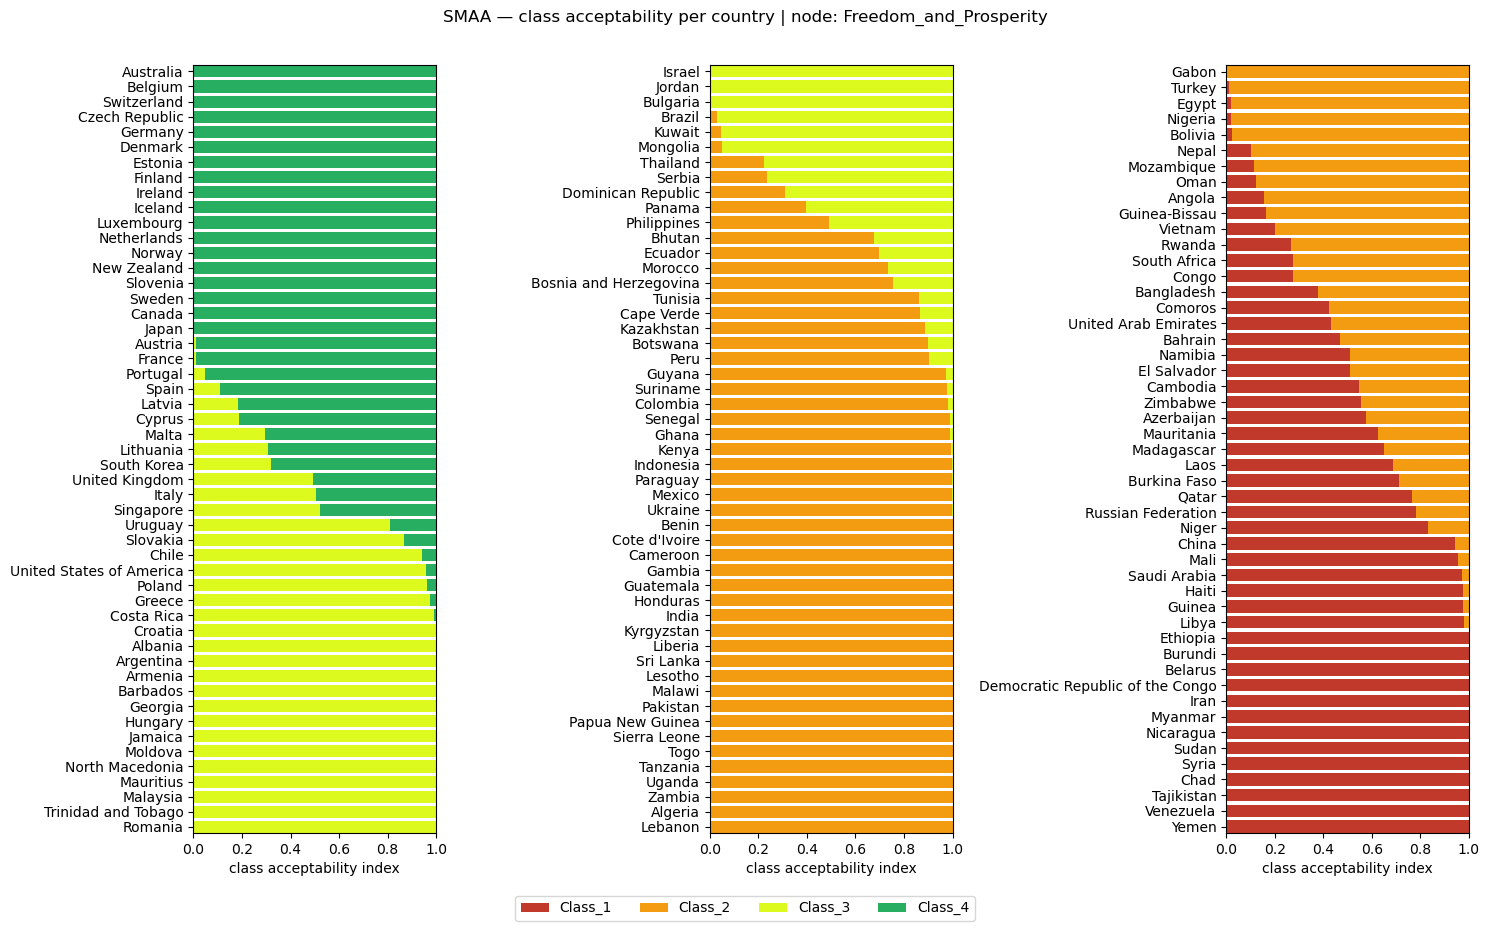

In [17]:
colors = {"Class_1": "#c0392b", "Class_2": "#f39c12", "Class_3": "#ddfa1f", "Class_4": "#27ae60"}

plot_acceptability_smaa(acceptability, categories, colors, "Freedom_and_Prosperity")

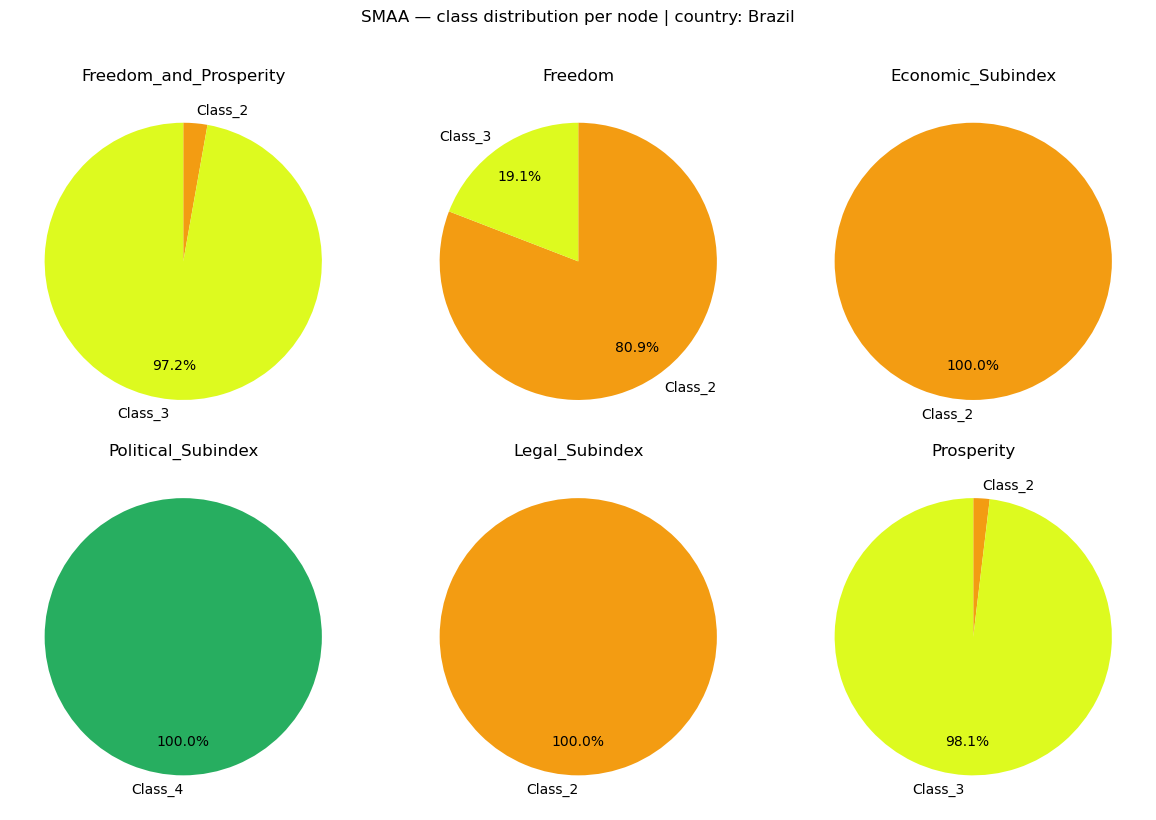

In [18]:
plot_country_pies_smaa(acceptability, nodes, categories, colors, "Brazil")

# SMAA-TRI

## Varying weights

In [19]:
# Varying-weights version
N_SIM = 10000          
SEED = 42             
rng = np.random.default_rng(SEED)
nodes = list(lambdas.keys())
alt_dicts = {name: df.loc[name].to_dict() for name in df.index}
def sample_weights(node, weight, rng, out=None):
    """Split `weight` among the children with Dirichlet(1,...,1) and recurse down to the leaves. 
    Preserves the hierarchy: on average it keeps each dimension's expected weight (Freedom≈0.5, etc.)."""
    if out is None:
        out = {}
    if node.is_leaf():
        out[node.leaf_id] = weight
        return out
    fracs = rng.dirichlet(np.ones(len(node.children)))
    for child, f in zip(node.children, fracs):
        sample_weights(child, weight * f, rng, out)
    return out

# counts_w[country][node] -> Counter({class: number of times})
counts_w = {c: {n: Counter() for n in nodes} for c in df.index}
params_varying_w = []

for _ in range(N_SIM):
    w   = sample_weights(Root, 1.0, rng)
    lam = compute_lambdas(Root, w, lambda_frac)
    q_s  = {lf: rng.uniform(3, 5)  for lf in leaves}
    p_s  = {lf: rng.uniform(5, 7)  for lf in leaves}
    v_s  = {lf: rng.uniform(30, 50) for lf in leaves}
    b1_s = {lf: rng.uniform(35, 45) for lf in leaves}
    b2_s = {lf: rng.uniform(55, 65) for lf in leaves}
    b3_s = {lf: rng.uniform(75, 85) for lf in leaves}
    model.q, model.p, model.v = q_s, p_s, v_s
    model.weights, model.lambdas = w, lam
    model.profiles = {"b1": b1_s, "b2": b2_s, "b3": b3_s}

    params_varying_w.append(
        {"weights": w, "lambdas": lam,
         "q": q_s, "p": p_s, "v": v_s, "b1": b1_s, "b2": b2_s, "b3": b3_s}
    )

    for name, alt in alt_dicts.items():
        assigned = model.assign_all_nodes(alt, procedure="pessimistic")
        for n in nodes:
            counts_w[name][n][assigned[n]] += 1

# restore the base-scenario parameters in the model
model.weights, model.lambdas = weights, lambdas
model.q, model.p, model.v, model.profiles = q, p, v, profiles

params_varying_w_df = params_to_df(params_varying_w)
print(f"Simulation finished: {N_SIM} iterations.")
params_varying_w_df

Simulation finished: 10000 iterations.


param           weights                                                        \
id        Proper_Rights Trade_Freedom Investm_Freedom Womens_Economic_Freedom   
iteration                                                                       
0              0.105283      0.102189        0.226437                0.005747   
1              0.053300      0.089674        0.060781                0.086729   
2              0.069828      0.320778        0.082074                0.210903   
3              0.019316      0.010827        0.000394                0.000044   
4              0.001048      0.006473        0.004561                0.000668   
...                 ...           ...             ...                     ...   
9995           0.000084      0.001191        0.006337                0.003355   
9996           0.002359      0.000731        0.000026                0.000648   
9997           0.000363      0.000045        0.000136                0.000210   
9998           0.021112      0.082359        0.080484                0.020836   
9999           0.141162      0.003578        0.070248                0.050808   

param                                                    \
id        PF_Elections Civil_Liberties Political_Rights   
iteration                                                 
0             0.013711        0.000923         0.014267   
1             0.014776        0.019177         0.000899   
2             0.034898        0.001948         0.016849   
3             0.002521        0.014475         0.091618   
4             0.014758        0.082914         0.019731   
...                ...             ...              ...   
9995          0.002298        0.003574         0.000517   
9996          0.000942        0.002246         0.002967   
9997          0.062581        0.024319         0.296419   
9998          0.388504        0.274480         0.008183   
9999          0.010090        0.000494         0.014315   

param                                                                  \
id        Legislative_Constraints_on_the_Executive Clarity_of_the_Law   
iteration                                                               
0                                         0.022682           0.002829   
1                                         0.049665           0.126588   
2                                         0.073703           0.000325   
3                                         0.005275           0.002179   
4                                         0.035162           0.154382   
...                                            ...                ...   
9995                                      0.002694           0.016953   
9996                                      0.000400           0.000109   
9997                                      0.072964           0.013622   
9998                                      0.039605           0.003308   
9999                                      0.011081           0.026091   

param                                              ...  \
id        Judicial_Independence_and_Effectiveness  ...   
iteration                                          ...   
0                                        0.009007  ...   
1                                        0.029304  ...   
2                                        0.004232  ...   
3                                        0.000131  ...   
4                                        0.037000  ...   
...                                           ...  ...   
9995                                     0.018849  ...   
9996                                     0.000861  ...   
9997                                     0.016957  ...   
9998                                     0.000392  ...   
9999                                     0.028212  ...   

param                                          b3                             \
id        Judicial_Independence_and_Effectiveness Bureaucracy_and_Corruption   
iteration                                 

In [20]:
accept_w = {}
for name in df.index:
    row = {}
    for n in nodes:
        total = sum(counts_w[name][n].values())  
        for c in categories:
            row[(n, c)] = counts_w[name][n][c] / total
    accept_w[name] = row

acceptability_w = pd.DataFrame(accept_w).T
acceptability_w.columns = pd.MultiIndex.from_tuples(acceptability_w.columns, names=["node", "class"])
acceptability_w = acceptability_w[[(n, c) for n in nodes for c in categories]]

acceptability_w

node                 Freedom_and_Prosperity                         Freedom  \
class                               Class_1 Class_2 Class_3 Class_4 Class_1   
Angola                               0.3161  0.6838  0.0001  0.0000  0.8451   
Albania                              0.0000  0.0645  0.9341  0.0014  0.0000   
United Arab Emirates                 0.4653  0.5347  0.0000  0.0000  0.9408   
Argentina                            0.0003  0.1648  0.8327  0.0022  0.0021   
Armenia                              0.0000  0.1739  0.8246  0.0015  0.0000   
...                                     ...     ...     ...     ...     ...   
Vietnam                              0.2402  0.7592  0.0006  0.0000  0.8461   
Yemen                                0.9883  0.0117  0.0000  0.0000  1.0000   
South Africa                         0.3150  0.6850  0.0000  0.0000  0.0005   
Zambia                               0.1091  0.8548  0.0361  0.0000  0.0196   
Zimbabwe                             0.4742  0.5258  0.0000  0.0000  0.9337   

node                                         Economic_Subindex          ...  \
class                Class_2 Class_3 Class_4           Class_1 Class_2  ...   
Angola                0.1549  0.0000  0.0000            0.8961  0.1039  ...   
Albania               0.4338  0.5653  0.0009            0.0000  0.7693  ...   
United Arab Emirates  0.0592  0.0000  0.0000            0.0000  0.5076  ...   
Argentina             0.7379  0.2598  0.0002            0.0000  0.9686  ...   
Armenia               0.6088  0.3907  0.0005            0.0000  0.2344  ...   
...                      ...     ...     ...               ...     ...  ...   
Vietnam               0.1539  0.0000  0.0000            0.0000  0.5397  ...   
Yemen                 0.0000  0.0000  0.0000            0.9552  0.0448  ...   
South Africa          0.7612  0.2370  0.0013            0.0045  0.9699  ...   
Zambia                0.7948  0.1856  0.0000            0.0000  0.8848  ...   
Zimbabwe              0.0663  0.0000  0.0000            0.9988  0.0012  ...   

node                 Political_Subindex         Legal_Subindex          \
class                           Class_3 Class_4        Class_1 Class_2   
Angola                           0.0000  0.0000         0.4142  0.5858   
Albania                          0.7316  0.2684         0.0000  0.7024   
United Arab Emirates             0.0000  0.0000         0.0075  0.8656   
Argentina                        0.0000  1.0000         0.0187  0.9248   
Armenia                          0.8656  0.1343         0.0000  0.9933   
...                                 ...     ...            ...     ...   
Vietnam                          0.0000  0.0000         0.4291  0.5705   
Yemen                            0.0000  0.0000         1.0000  0.0000   
South Africa                     0.0000  1.0000         0.0000  0.9445   
Zambia                           0.2269  0.7731         0.1589  0.8340   
Zimbabwe                         0.0033  0.0000         0.9968  0.0032   

node                                 Prosperity                          
class                Class_3 Class_4    Class_1 Class_2 Class_3 Class_4  
Angola                0.0000     0.0     0.0776  0.9155  0.0069  0.0000  
Albania               0.2976     0.0     0.0000  0.0065  0.9909  0.0026  
United Arab Emirates  0.1269     0.0     0.0000  0.2044  0.6067  0.1889  
Argentina             0.0565     0.0     0.0000  0.0000  0.8923  0.1077  
Armenia               0.0067     0.0     0.0000  0.0000  0.9865  0.0135  
...                      ...     ...        ...     ...     ...     ...  
Vietnam               0.0004     0.0     0.0000  0.0939  0.9055  0.0006  
Yemen                 0.0000     0.0     0.9270  0.0729  0.0001  0.0000  
South Africa          0.0555     0.0     0.8825  0.1175  0.0000  0.0000  
Zambia                0.0071     0.0     0.4268  0.5731  0.0001  0.0000  
Zimbabwe              0.0000     0.0     0.0595  0.9365  0.0040  0.0000  

[151 rows x 24 col

In [21]:
class_acceptability_smaa(acceptability_w, categories, "Freedom_and_Prosperity").round(3)

class,Class_1,Class_2,Class_3,Class_4
Ireland,0.000,0.000,0.000,1.000
Denmark,0.000,0.000,0.000,1.000
Sweden,0.000,0.000,0.000,1.000
Finland,0.000,0.000,0.000,1.000
Switzerland,0.000,0.000,0.001,0.999
...,...,...,...,...
Belarus,0.962,0.038,0.000,0.000
Syria,0.982,0.018,0.000,0.000
Sudan,0.987,0.013,0.000,0.000
Yemen,0.988,0.012,0.000,0.000


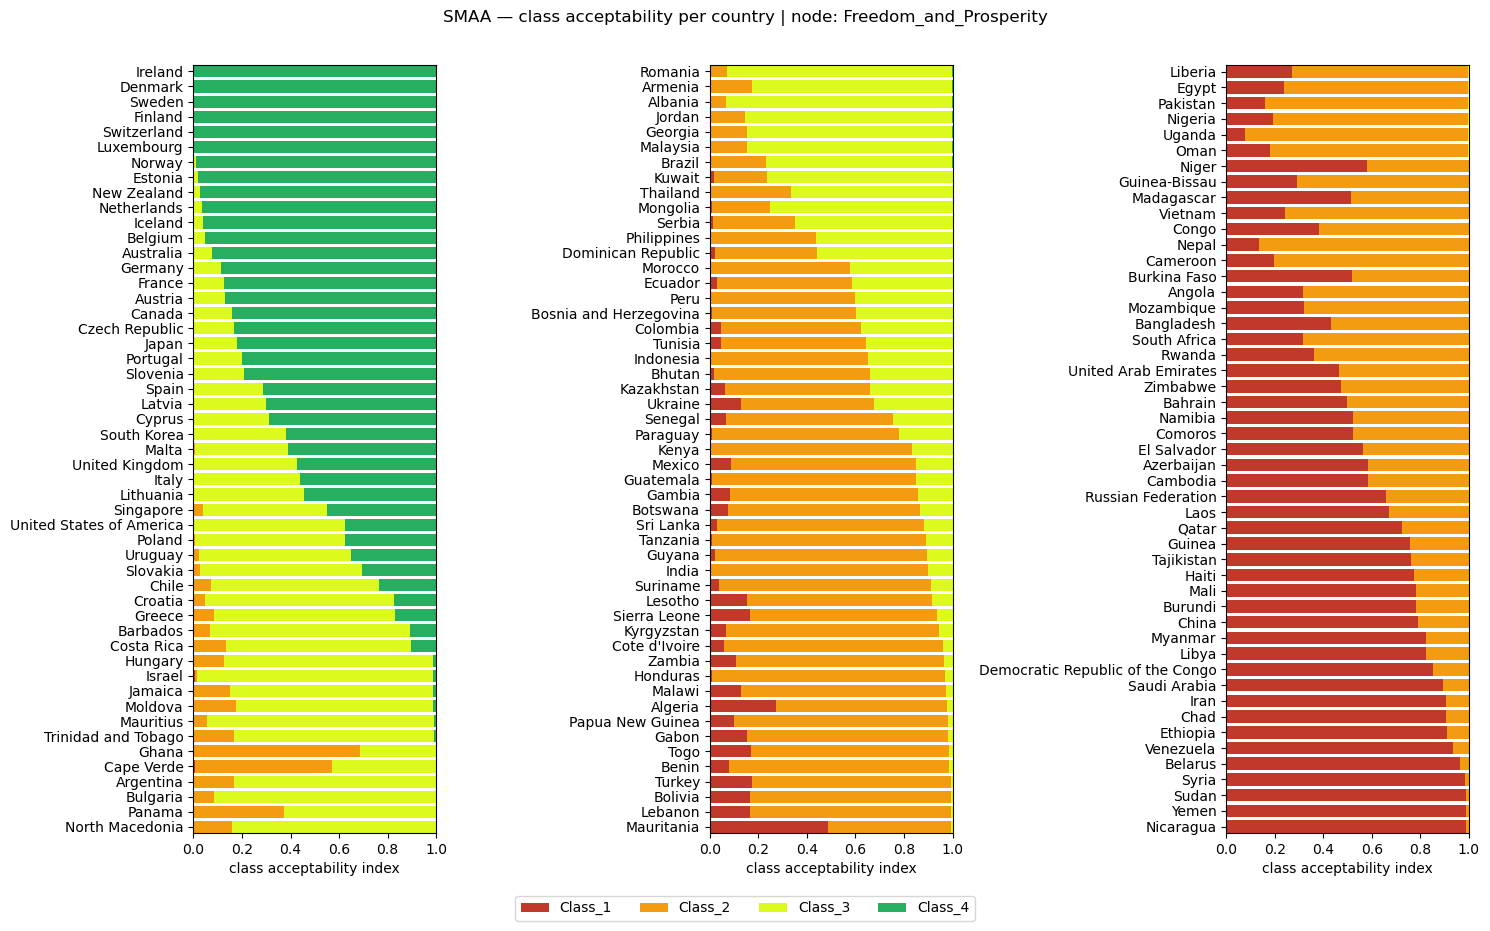

In [22]:
plot_acceptability_smaa(acceptability_w, categories, colors, "Freedom_and_Prosperity")

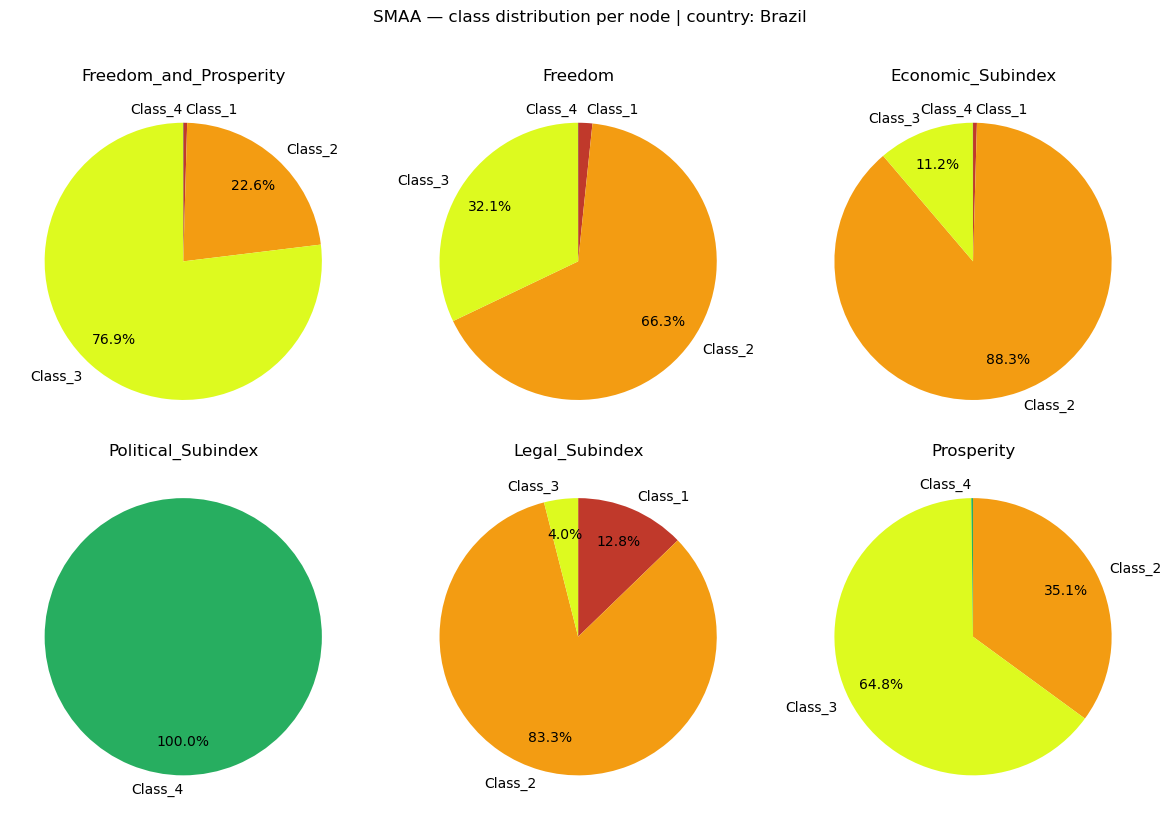

In [23]:
plot_country_pies_smaa(acceptability_w, nodes, categories, colors, "Brazil")

# SMAA-TRI

## Fixed Freedom/Prosperity split (0.5 / 0.5), varying children weights

In [24]:
# Fixed Freedom/Prosperity split (0.5 / 0.5), children weights vary
N_SIM = 10000          
SEED = 42             
rng = np.random.default_rng(SEED)
nodes = list(lambdas.keys())
alt_dicts = {name: df.loc[name].to_dict() for name in df.index}

# counts_fp[country][node] -> Counter({class: number of times})
counts_fp = {c: {n: Counter() for n in nodes} for c in df.index}
params_fixed_fp = []

for _ in range(N_SIM):
    # pin the top-level split: Freedom = 0.5, Prosperity = 0.5,
    # vary everything below via Dirichlet (full cascade)
    w = {}
    sample_weights(Freedom,    0.5, rng, w)
    sample_weights(Prosperity, 0.5, rng, w)
    lam = compute_lambdas(Root, w, lambda_frac)
    q_s  = {lf: rng.uniform(3, 5)  for lf in leaves}
    p_s  = {lf: rng.uniform(5, 7)  for lf in leaves}
    v_s  = {lf: rng.uniform(30, 50) for lf in leaves}
    b1_s = {lf: rng.uniform(35, 45) for lf in leaves}
    b2_s = {lf: rng.uniform(55, 65) for lf in leaves}
    b3_s = {lf: rng.uniform(75, 85) for lf in leaves}
    model.q, model.p, model.v = q_s, p_s, v_s
    model.weights, model.lambdas = w, lam
    model.profiles = {"b1": b1_s, "b2": b2_s, "b3": b3_s}

    params_fixed_fp.append(
        {"weights": w, "lambdas": lam,
         "q": q_s, "p": p_s, "v": v_s, "b1": b1_s, "b2": b2_s, "b3": b3_s}
    )

    for name, alt in alt_dicts.items():
        assigned = model.assign_all_nodes(alt, procedure="pessimistic")
        for n in nodes:
            counts_fp[name][n][assigned[n]] += 1

# restore the base-scenario parameters in the model
model.weights, model.lambdas = weights, lambdas
model.q, model.p, model.v, model.profiles = q, p, v, profiles

params_fixed_fp_df = params_to_df(params_fixed_fp)
print(f"Simulation finished: {N_SIM} iterations.")
params_fixed_fp_df

Simulation finished: 10000 iterations.


param           weights                                                        \
id        Proper_Rights Trade_Freedom Investm_Freedom Womens_Economic_Freedom   
iteration                                                                       
0              0.014620      0.004516        0.075904                0.073673   
1              0.028203      0.113856        0.033126                0.186779   
2              0.007475      0.009377        0.001940                0.031653   
3              0.002413      0.000149        0.000807                0.001472   
4              0.051129      0.067736        0.009987                0.043136   
...                 ...           ...             ...                     ...   
9995           0.010957      0.050316        0.012453                0.000682   
9996           0.015012      0.052887        0.015878                0.028504   
9997           0.033577      0.031208        0.015720                0.000532   
9998           0.073605      0.107005        0.038419                0.021561   
9999           0.009192      0.108112        0.065026                0.241209   

param                                                    \
id        PF_Elections Civil_Liberties Political_Rights   
iteration                                                 
0             0.118548        0.003009         0.039710   
1             0.008237        0.013857         0.009393   
2             0.164257        0.022649         0.032465   
3             0.125893        0.012490         0.224893   
4             0.033418        0.001161         0.013891   
...                ...             ...              ...   
9995          0.045491        0.023881         0.082659   
9996          0.052033        0.013127         0.018859   
9997          0.015935        0.024478         0.158536   
9998          0.009867        0.024574         0.069762   
9999          0.010445        0.011572         0.002625   

param                                                                  \
id        Legislative_Constraints_on_the_Executive Clarity_of_the_Law   
iteration                                                               
0                                         0.002673           0.039682   
1                                         0.013402           0.008442   
2                                         0.149140           0.006444   
3                                         0.126060           0.000062   
4                                         0.023156           0.018092   
...                                            ...                ...   
9995                                      0.094211           0.028816   
9996                                      0.000737           0.056283   
9997                                      0.081468           0.054000   
9998                                      0.009386           0.005198   
9999                                      0.003099           0.013908   

param                                              ...  \
id        Judicial_Independence_and_Effectiveness  ...   
iteration                                          ...   
0                                        0.063087  ...   
1                                        0.010957  ...   
2                                        0.016560  ...   
3                                        0.000007  ...   
4                                        0.111753  ...   
...                                           ...  ...   
9995                                     0.058965  ...   
9996                                     0.024879  ...   
9997                                     0.003912  ...   
9998                                     0.044244  ...   
9999                                     0.005304  ...   

param                                          b3                             \
id        Judicial_Independence_and_Effectiveness Bureaucracy_and_Corruption   
iteration                                 

In [25]:
accept_fp = {}
for name in df.index:
    row = {}
    for n in nodes:
        total = sum(counts_fp[name][n].values())  
        for c in categories:
            row[(n, c)] = counts_fp[name][n][c] / total
    accept_fp[name] = row

acceptability_fp = pd.DataFrame(accept_fp).T
acceptability_fp.columns = pd.MultiIndex.from_tuples(acceptability_fp.columns, names=["node", "class"])
acceptability_fp = acceptability_fp[[(n, c) for n in nodes for c in categories]]

acceptability_fp

node                 Freedom_and_Prosperity                         Freedom  \
class                               Class_1 Class_2 Class_3 Class_4 Class_1   
Angola                               0.2812  0.7188  0.0000  0.0000  0.8578   
Albania                              0.0000  0.0268  0.9731  0.0001  0.0000   
United Arab Emirates                 0.4702  0.5298  0.0000  0.0000  0.9987   
Argentina                            0.0000  0.0994  0.8999  0.0007  0.0029   
Armenia                              0.0000  0.1254  0.8739  0.0007  0.0000   
...                                     ...     ...     ...     ...     ...   
Vietnam                              0.2149  0.7851  0.0000  0.0000  0.9565   
Yemen                                0.9990  0.0010  0.0000  0.0000  1.0000   
South Africa                         0.3025  0.6975  0.0000  0.0000  0.0003   
Zambia                               0.0710  0.9265  0.0025  0.0000  0.0223   
Zimbabwe                             0.5370  0.4630  0.0000  0.0000  0.9308   

node                                         Economic_Subindex          ...  \
class                Class_2 Class_3 Class_4           Class_1 Class_2  ...   
Angola                0.1422  0.0000     0.0            0.8859  0.1141  ...   
Albania               0.2726  0.7274     0.0            0.0000  0.7487  ...   
United Arab Emirates  0.0013  0.0000     0.0            0.0000  0.4892  ...   
Argentina             0.7126  0.2845     0.0            0.0000  0.9705  ...   
Armenia               0.4906  0.5094     0.0            0.0000  0.2322  ...   
...                      ...     ...     ...               ...     ...  ...   
Vietnam               0.0435  0.0000     0.0            0.0000  0.5240  ...   
Yemen                 0.0000  0.0000     0.0            0.9483  0.0517  ...   
South Africa          0.7433  0.2564     0.0            0.0035  0.9767  ...   
Zambia                0.8631  0.1146     0.0            0.0000  0.8780  ...   
Zimbabwe              0.0692  0.0000     0.0            0.9985  0.0015  ...   

node                 Political_Subindex         Legal_Subindex          \
class                           Class_3 Class_4        Class_1 Class_2   
Angola                           0.0000  0.0000         0.4011  0.5989   
Albania                          0.7252  0.2748         0.0000  0.6894   
United Arab Emirates             0.0000  0.0000         0.0070  0.8716   
Argentina                        0.0000  1.0000         0.0179  0.9351   
Armenia                          0.8748  0.1251         0.0000  0.9941   
...                                 ...     ...            ...     ...   
Vietnam                          0.0000  0.0000         0.4115  0.5884   
Yemen                            0.0000  0.0000         1.0000  0.0000   
South Africa                     0.0000  1.0000         0.0000  0.9523   
Zambia                           0.2265  0.7735         0.1588  0.8396   
Zimbabwe                         0.0015  0.0000         0.9966  0.0034   

node                                 Prosperity                          
class                Class_3 Class_4    Class_1 Class_2 Class_3 Class_4  
Angola                0.0000     0.0     0.0767  0.9198  0.0035  0.0000  
Albania               0.3106     0.0     0.0000  0.0078  0.9892  0.0030  
United Arab Emirates  0.1214     0.0     0.0000  0.1962  0.6986  0.1052  
Argentina             0.0470     0.0     0.0000  0.0000  0.8598  0.1402  
Armenia               0.0059     0.0     0.0000  0.0000  0.9835  0.0165  
...                      ...     ...        ...     ...     ...     ...  
Vietnam               0.0001     0.0     0.0000  0.0989  0.9011  0.0000  
Yemen                 0.0000     0.0     0.9551  0.0449  0.0000  0.0000  
South Africa          0.0477     0.0     0.9771  0.0229  0.0000  0.0000  
Zambia                0.0016     0.0     0.3057  0.6943  0.0000  0.0000  
Zimbabwe              0.0000     0.0     0.0556  0.9427  0.0017  0.0000  

[151 rows x 24 col

In [26]:
class_acceptability_smaa(acceptability_fp, categories, "Freedom_and_Prosperity").round(3)

class,Class_1,Class_2,Class_3,Class_4
Denmark,0.000,0.000,0.0,1.0
Ireland,0.000,0.000,0.0,1.0
Sweden,0.000,0.000,0.0,1.0
Switzerland,0.000,0.000,0.0,1.0
Finland,0.000,0.000,0.0,1.0
...,...,...,...,...
Belarus,0.994,0.006,0.0,0.0
Nicaragua,0.995,0.005,0.0,0.0
Syria,0.999,0.001,0.0,0.0
Yemen,0.999,0.001,0.0,0.0


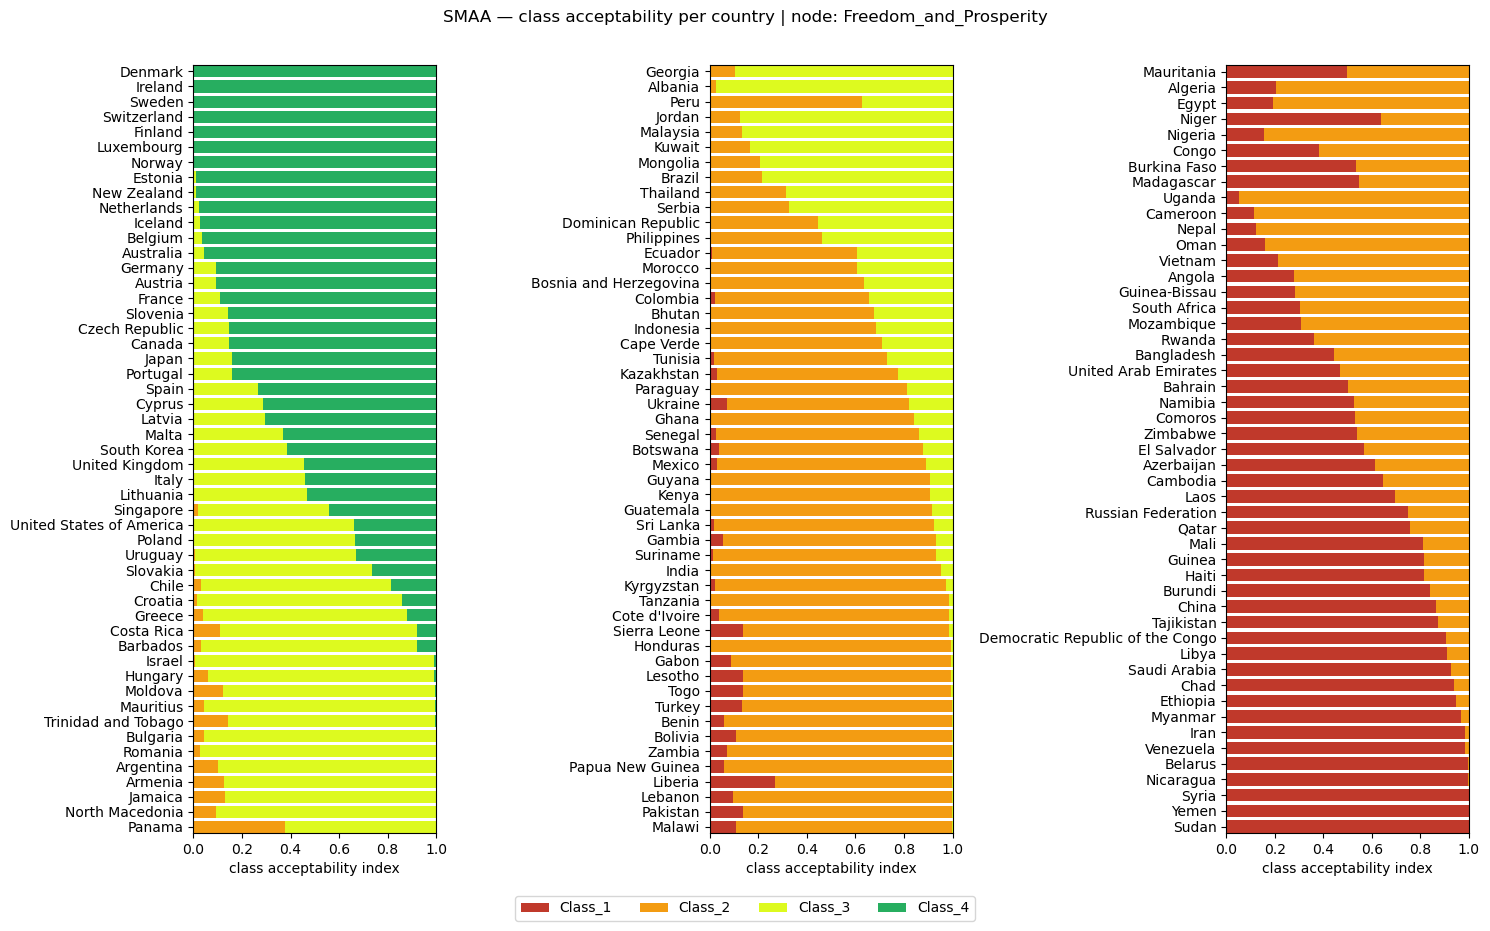

In [27]:
plot_acceptability_smaa(acceptability_fp, categories, colors, "Freedom_and_Prosperity")

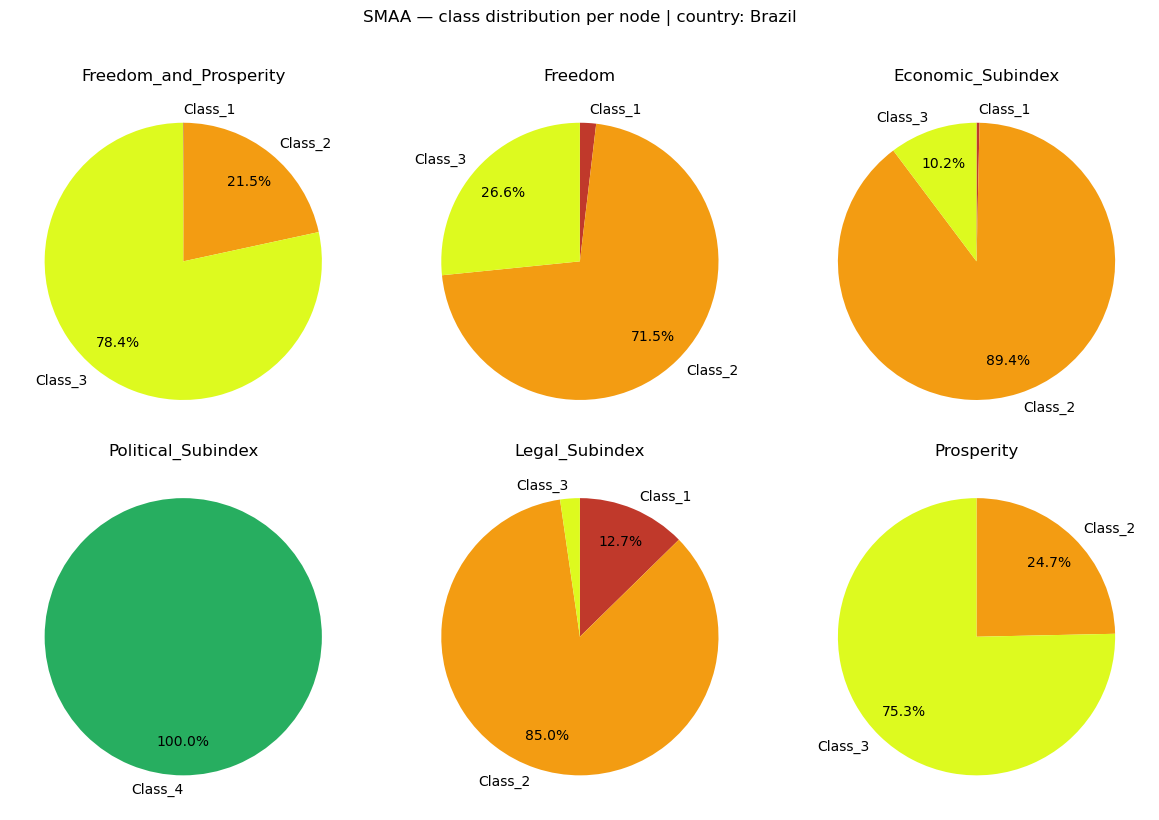

In [28]:
plot_country_pies_smaa(acceptability_fp, nodes, categories, colors, "Brazil")